In [ ]:
import pandas as pd
import numpy as np

In [ ]:
#Timestamp
pd.Timestamp('6th Jan 2023 8:10')

In [ ]:
#Date Time Stamp Index
pd.DatetimeIndex([pd.Timestamp('6th Jan 2023 8:10'),pd.Timestamp('7th Jan 2023 8:10'),pd.Timestamp('8th Jan 2023 8:10')])

In [ ]:
#daterange function
pd.date_range(start = '2023-1-2',end='2023-2-2',freq = 'D')

In [ ]:
#to datetime object 
# pd.to_datetime()
#will convert directly this object to the datetime index column

In [ ]:
google_df = pd.read_csv('Dataset\Copy of google.csv')
deliveries_df = pd.read_csv('Dataset\Copy of deliveries.csv')


In [ ]:
#time delta object 
# difference between two time stamp

t1 = pd.Timestamp('2023/01/06 00:00:00')
t2 = pd.Timestamp('2023/01/26 10:00:00')

t2-t1 # + means time is still remainded
      # - time had already passed

In [ ]:
#standalone creation - Object creation

pd.Timedelta(days=2)

In [ ]:
# airithmatic 
pd.Timestamp('2025/06/21 17:05:30') + pd.Timedelta(days=2)

In [ ]:
pd.date_range(start= '2023/01/06' ,end = '2023/01/10',freq='D') +  pd.Timedelta(days=2)

In [ ]:
deliveries_df['order_date'] = pd.to_datetime(deliveries_df['order_date'])
deliveries_df['delivery_date'] = pd.to_datetime(deliveries_df['delivery_date'])

In [ ]:
(deliveries_df['delivery_date']  - deliveries_df['order_date']).mean() 

In [ ]:
#Time Series
# data - Financial data
# Natural Data - Rainfall measurement
# Event data - Covid data
# Medical data - Heart rate data monitoring

# Types of Operation done on Time Series
# Time Series Analysis
# Time Series Forecasting - Arima,LSTM
 

In [3]:
login_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3002 entries, 0 to 3001
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   1                    3002 non-null   int64 
 1   466                  3002 non-null   int64 
 2   2017-01-07 18:24:07  3002 non-null   object
 3   Unnamed: 3           2209 non-null   object
dtypes: int64(2), object(2)
memory usage: 93.9+ KB


In [4]:
google_df['Date'] = pd.to_datetime(google_df['Date'])

In [5]:
google_df.set_index('Date',inplace = True)  #make date as a index this will help a lot

In [6]:
#fetch a specific time

google_df.loc['2005/12/01']

Open         2.038360e+02
High         2.069443e+02
Low          2.033827e+02
Close        2.062718e+02
Adj Close    2.062718e+02
Volume       1.956285e+07
Name: 2005-12-01 00:00:00, dtype: float64

In [ ]:
#partial index

# google_df.loc['2021-12'] #this will be from same month date
google_df.loc['2021'] #this will be from same Year date


In [7]:
#Create a year name and month name data
google_df['Month'] = google_df.index.month_name() #why we dont required successorew
google_df['Weekday'] = google_df.index.day_name() #why we dont required successorew
google_df['quarter'] = google_df.index.quarter #why we dont required successorew

In [ ]:
google_df.pivot_table(index='Month',columns = 'Weekday',values ='Close',aggfunc='mean')

In [ ]:
#slicing
google_df.loc['2021-02-01': '2021-02-10']

In [8]:
#perticular date every year
google_df[google_df.index.isin(pd.date_range(start='2005-01-06', end ='2022-01-06',freq= pd.DateOffset(years = 1)))]

,Open,High,Low,Close,Adj Close,Volume,Month,Weekday,quarter
Date,,,,,,,,,
2005-01-06,97.175758,97.584229,93.509506,93.922951,93.922951,20852067,January,Thursday,1
2006-01-06,227.581970,234.371521,225.773743,231.960556,231.960556,35646914,January,Friday,1
2009-01-06,165.868286,169.763687,162.585587,166.406265,166.406265,12898566,January,Tuesday,1
2010-01-06,311.761444,311.761444,302.047852,302.994293,302.994293,7987226,January,Wednesday,1
2011-01-06,304.199799,308.060303,303.885956,305.604523,305.604523,4131026,January,Thursday,1
2012-01-06,328.344299,328.767700,323.681763,323.796326,323.796326,5405987,January,Friday,1
2014-01-06,554.426880,557.340942,551.154114,556.573853,556.573853,3551864,January,Monday,1
2015-01-06,513.589966,514.761719,499.678131,500.585632,500.585632,2899940,January,Tuesday,1
2016-01-06,730.000000,747.179993,728.919983,743.619995,743.619995,1947000,January,Wednesday,1


In [ ]:
#viz a single column

google_df['Close'].plot(kind = 'line')

In [ ]:
google_df[['Open','High','Low']].plot()

In [ ]:
#sub plot - Not working will do latter

ax = google_df.plot(subplots = True,layout=(1,2),sharex= False,sharey= False,linewidth= 0.7,fontsize= 10,legend= False,figsize=(15,10),title = ['Open','High','Low','close'])

In [ ]:
#plot for a perticular week/month/day

# google_df.loc['2022-01']['Close'].plot()

In [ ]:
#monthly trend
google_df['Close'].asfreq('ME').plot()

In [ ]:
#quartely data
google_df['Close'].asfreq('QE').plot()

In [ ]:
#frequency

google_df.asfreq('ME',method='bfill') # data will be added - You can fill the data using the method parameter

### reshampling - Frequency will be chnaged

upsampling - minutes to secondes
Downsamping = days to month

<Axes: xlabel='Date'>

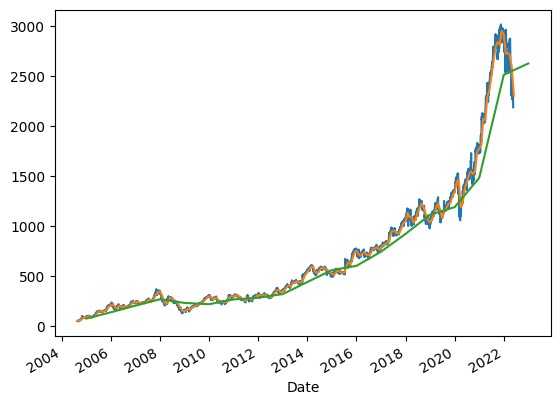

In [ ]:
#Down Sampling
google_df['Close'].plot()
google_df['Close'].resample('ME').mean().plot()
google_df['Close'].resample('YE').mean().plot()

<Axes: xlabel='Date'>

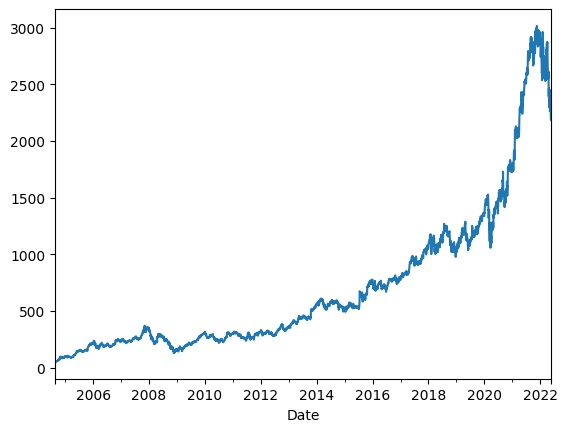

In [ ]:
#Up Sampling - Here you are having a nan value as you are increasing the value of the raws

google_df['Close'].resample('6h').interpolate(method = 'linear').plot()


### Rolling Window

rolling or moving average to smoothning the data 


In [24]:
google_df['Close'].rolling(3).mean()

Date
2004-08-19            NaN
2004-08-20            NaN
2004-08-23      52.810387
2004-08-24      53.562567
2004-08-25      53.179006
                 ...     
2022-05-16    2296.460043
2022-05-17    2320.063395
2022-05-18    2292.633382
2022-05-19    2265.653320
2022-05-20    2216.396647
Name: Close, Length: 4471, dtype: float64

1,2,3,4,5,6
Sampling Moving Average = nan,nan,(1+2+3)/3,(2+3+4)/3,(3+4+5)/3
Exponential Moving Average = nan,nan,(1*0.2+2*0.2+3*0.6),(2*0.2+3*0.2+4*0.6),(3*0.2+0.2*4+0.2*5)

<Axes: xlabel='Date'>

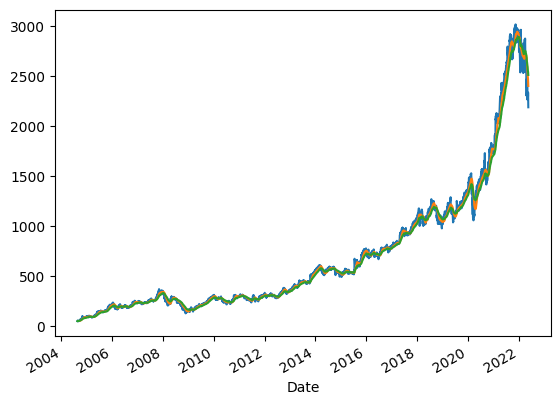

In [ ]:
google_df['Close'].plot(label='Original')
google_df['Close'].rolling(30).mean().plot(label='Rolling')
google_df['Close'].ewm(30).mean().plot(label='EWA')

This will shift the series of the data to the below

### shifting

In [37]:
google_df['Close'].shift(-1) #it will

Date
2004-08-19      53.952770
2004-08-20      54.495735
2004-08-23      52.239197
2004-08-24      52.802086
2004-08-25      53.753517
                 ...     
2022-05-16    2334.030029
2022-05-17    2248.020020
2022-05-18    2214.909912
2022-05-19    2186.260010
2022-05-20            NaN
Name: Close, Length: 4471, dtype: float64

In [40]:
login_df = pd.read_csv('Dataset\Copy of login.csv',header = None)
login_df.head()

,0,1,2,3
0,1,466,2017-01-07 18:24:07,Unnamed: 3
1,2,466,2017-01-07 18:24:55,NaN
2,3,458,2017-01-07 18:25:18,NaN
3,4,458,2017-01-07 18:26:21,NaN
4,5,592,2017-01-07 19:09:59,NaN


In [43]:
login_df.rename(columns = {1:'user_id',2:'login_time'},inplace=True)

In [45]:
login_df['user_id'].value_counts(ascending = False)

user_id
413     222
458     208
492     162
882     140
592     122
       ... 
1275      1
1276      1
639       1
1279      1
636       1
Name: count, Length: 433, dtype: int64

In [46]:
login_df[login_df['user_id']==413]

,0,user_id,login_time,3
11,12,413,2017-01-09 12:29:25,NaN
12,13,413,2017-01-09 12:40:39,NaN
14,15,413,2017-01-09 14:08:04,NaN
33,34,413,2017-01-10 14:36:23,NaN
35,36,413,2017-01-10 15:22:45,NaN
...,...,...,...,...
2958,2959,413,2017-12-29 18:20:32,182.68.234.163
2963,2964,413,2017-12-30 13:41:21,42.111.121.84
2974,2975,413,2018-01-01 15:16:25,182.68.240.149
2982,2983,413,2018-01-02 18:15:45,182.68.99.205


In [48]:
login_df['login_time'] = pd.to_datetime(login_df['login_time'])

In [49]:
#to find out how many time vistitor is coming to login

login_df['login_time_shifted'] = login_df['login_time'].shift(1)
login_df

,0,user_id,login_time,3,login_time_shifted
0,1,466,2017-01-07 18:24:07,Unnamed: 3,NaT
1,2,466,2017-01-07 18:24:55,NaN,2017-01-07 18:24:07
2,3,458,2017-01-07 18:25:18,NaN,2017-01-07 18:24:55
3,4,458,2017-01-07 18:26:21,NaN,2017-01-07 18:25:18
4,5,592,2017-01-07 19:09:59,NaN,2017-01-07 18:26:21
...,...,...,...,...,...
2998,2999,1307,2018-01-04 10:48:28,183.82.121.201,2018-01-04 10:43:43
2999,3000,1230,2018-01-04 11:22:00,47.247.147.114,2018-01-04 10:48:28
3000,3001,1307,2018-01-04 13:13:44,183.82.121.201,2018-01-04 11:22:00
3001,3002,1307,2018-01-04 13:13:45,183.82.121.201,2018-01-04 13:13:44


In [50]:
(login_df['login_time'] - login_df['login_time_shifted']).mean()

Timedelta('0 days 02:53:33.576615589')